In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.style.use('default')
sns.set()

In [2]:
df = pd.read_csv('messyData.csv')

# View data
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,NaN,NaN,NaN,2.0,NaN,NaN,Netherlands,No,1.0,120569.0
1,NaN,16.0,Diploma,NaN,Media,NaN,Remote,NaN,NaN,105757.0
2,NaN,18.0,Bachelor,9.0,Manufacturing,Enterprise,Sweden,No,NaN,180750.0
3,NaN,NaN,Master,NaN,NaN,Small,Singapore,Hybrid,NaN,101968.0
4,NaN,7.0,Master,NaN,Education,NaN,Remote,No,NaN,162627.0


In [3]:
# Shape of dataset
print("Shape:", df.shape)

# Data types
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

Shape: (275000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275000 entries, 0 to 274999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   job_title         137347 non-null  object 
 1   experience_years  137418 non-null  float64
 2   education_level   137575 non-null  object 
 3   skills_count      137695 non-null  float64
 4   industry          137650 non-null  object 
 5   company_size      137783 non-null  object 
 6   location          137442 non-null  object 
 7   remote_work       137127 non-null  object 
 8   certifications    137133 non-null  float64
 9   salary            137851 non-null  float64
dtypes: float64(4), object(6)
memory usage: 21.0+ MB


job_title           137653
experience_years    137582
education_level     137425
skills_count        137305
industry            137350
company_size        137217
location            137558
remote_work         137873
certifications      137867
salary              137149
dtype: int64

In [4]:
# Fill numeric missing values with median
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values with mode
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [7]:
# Example: converting salary column to numeric if messy
df['salary'] = pd.to_numeric(df['salary'], errors='coerce')

In [8]:
# Remove extreme salary outliers
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['salary'] >= Q1 - 1.5*IQR) & (df['salary'] <= Q3 + 1.5*IQR)]

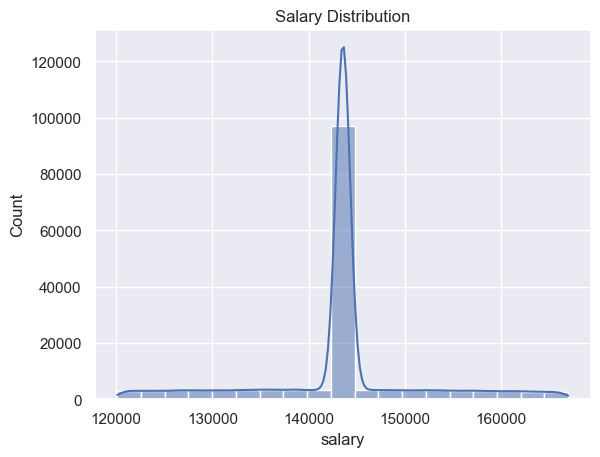

In [9]:
plt.figure()
sns.histplot(df['salary'], kde=True)
plt.title("Salary Distribution")
plt.show()

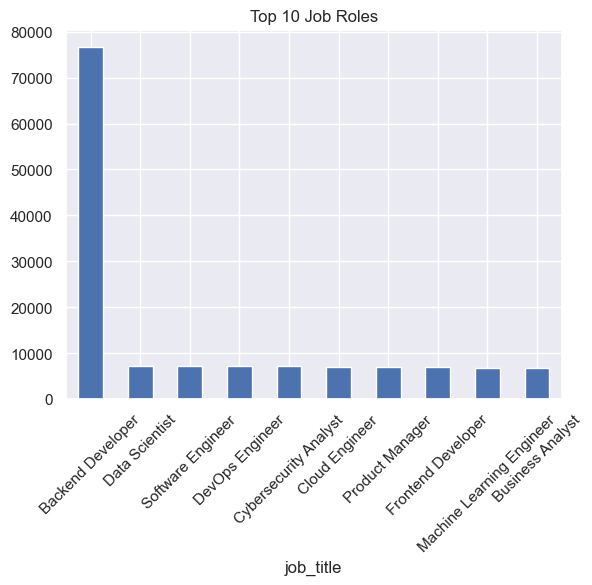

In [10]:
plt.figure()
df['job_title'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Job Roles")
plt.xticks(rotation=45)
plt.show()

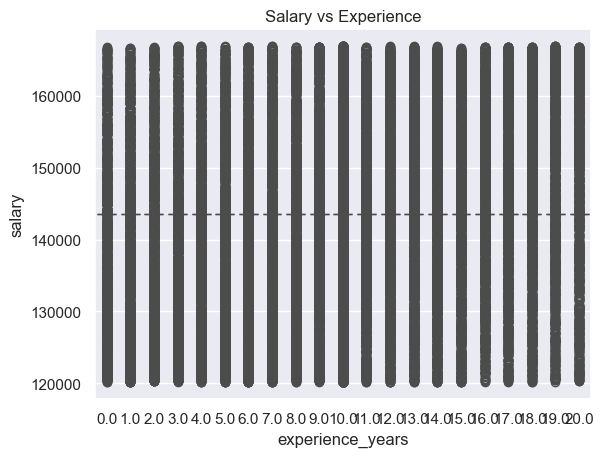

In [12]:
plt.figure()
sns.boxplot(x='experience_years', y='salary', data=df)
plt.title("Salary vs Experience")
plt.show()

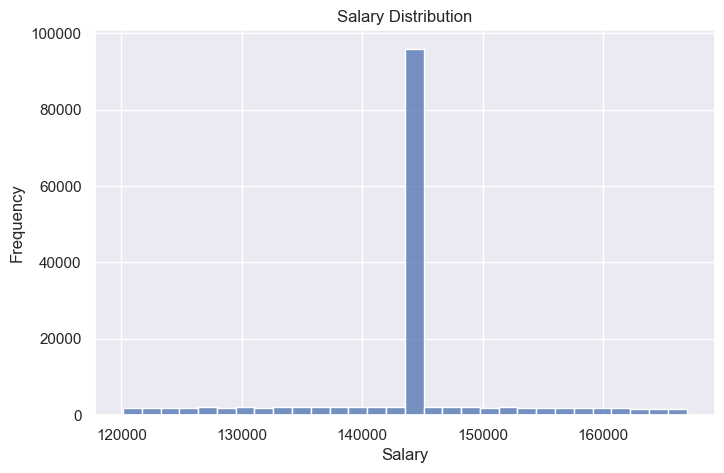

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['salary'], bins=30)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

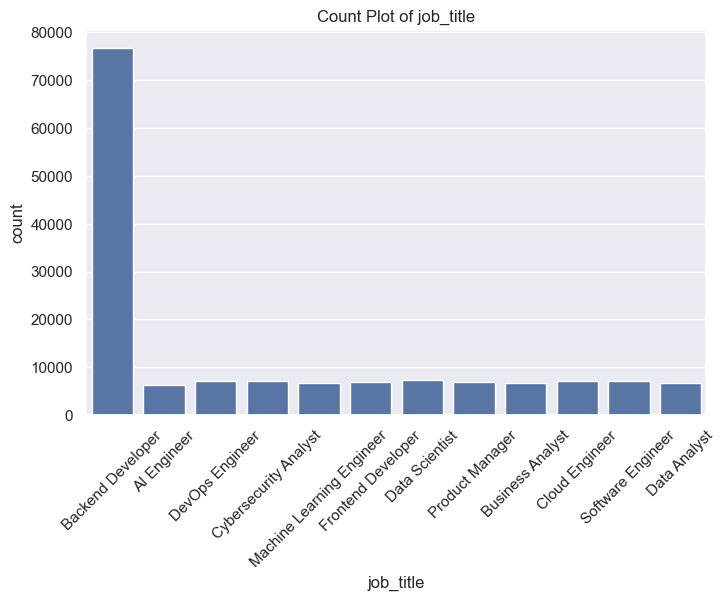

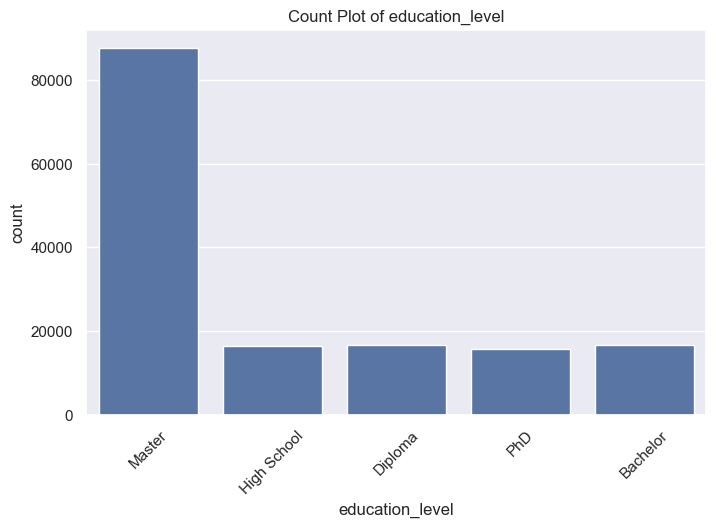

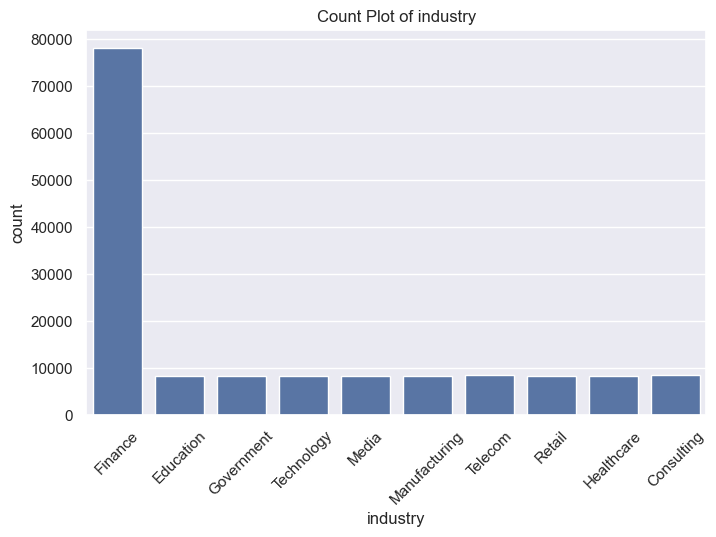

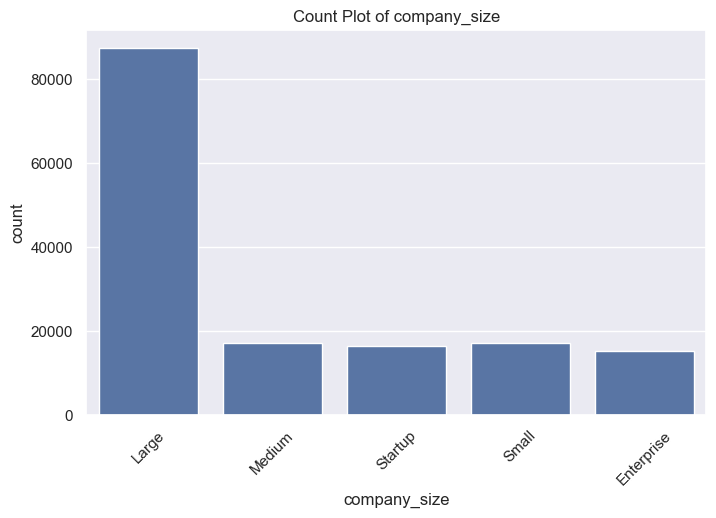

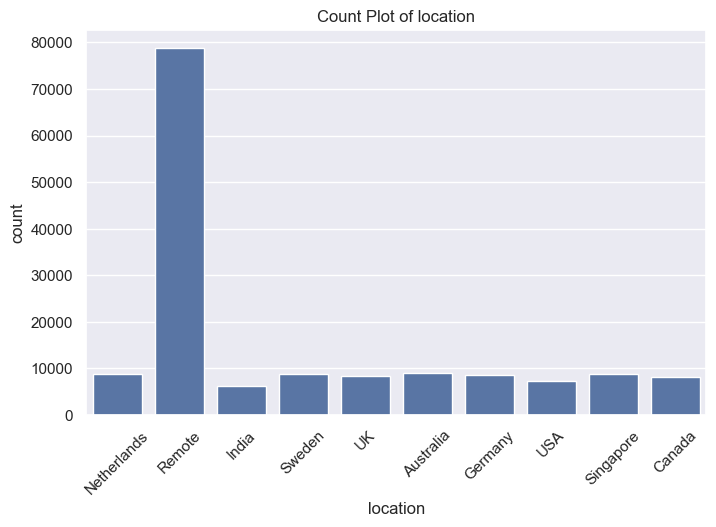

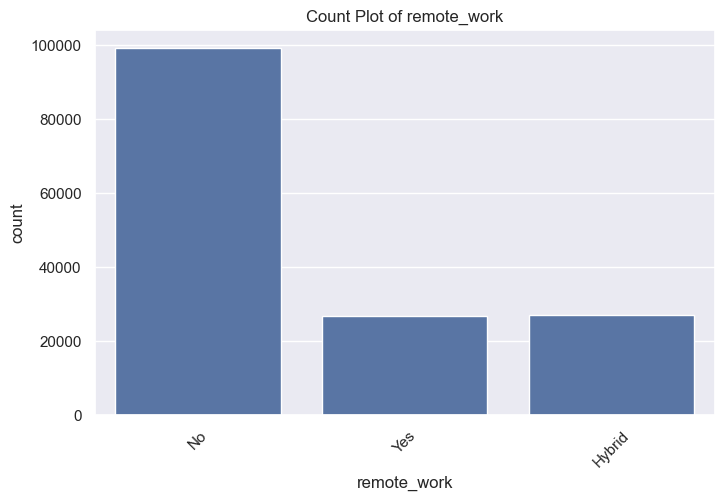

In [14]:
# Loop through categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(x=col, data=df)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

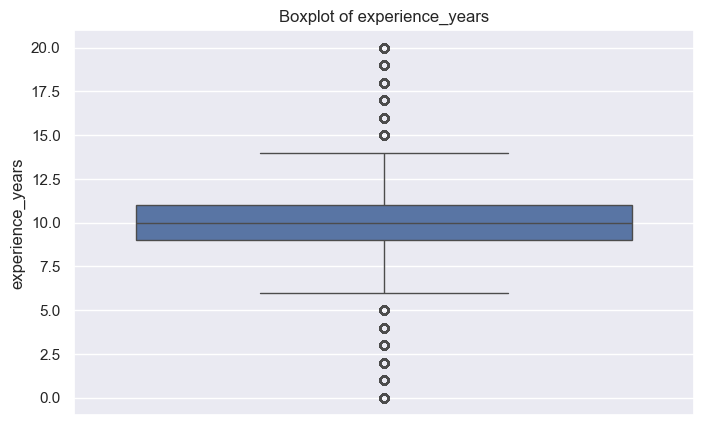

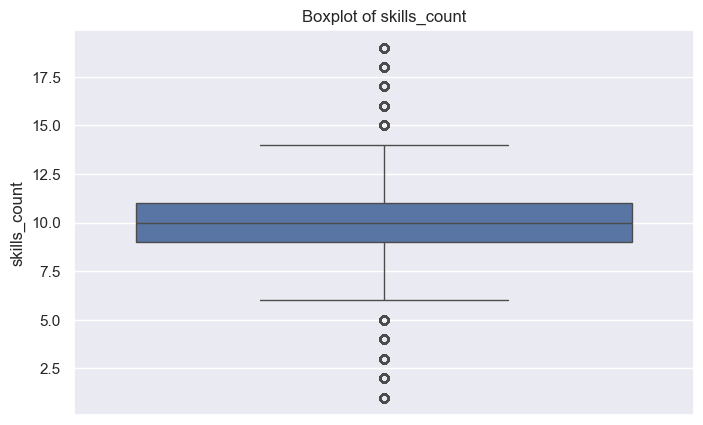

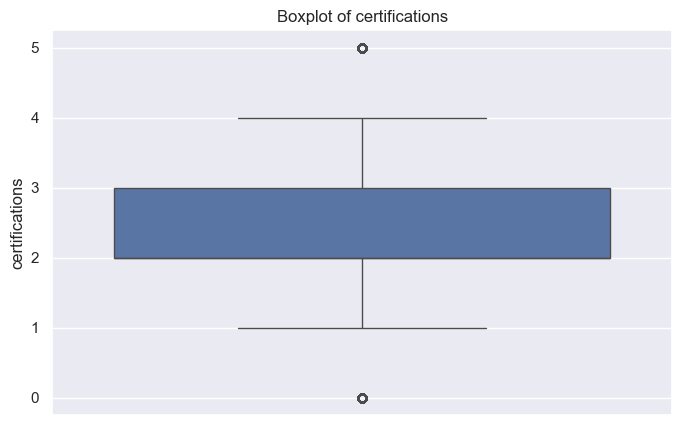

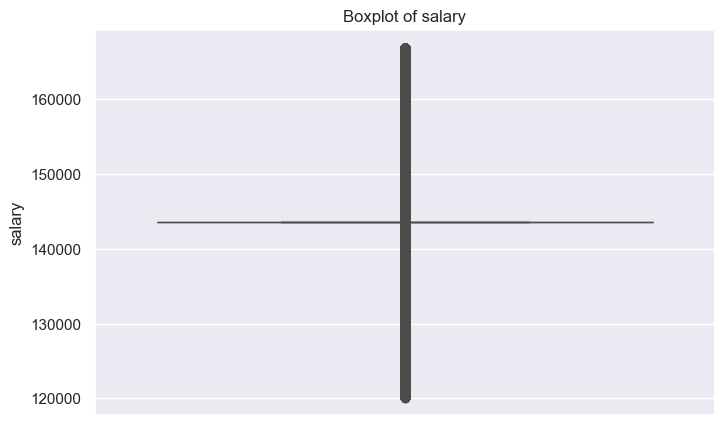

In [15]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

<Axes: >

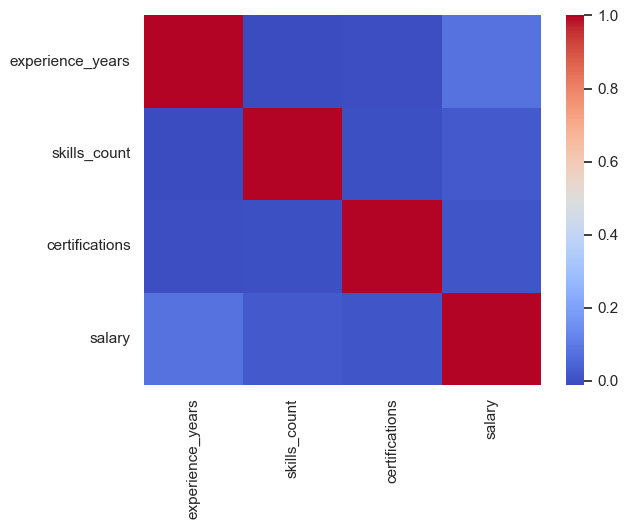

In [17]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=False, cmap='coolwarm')

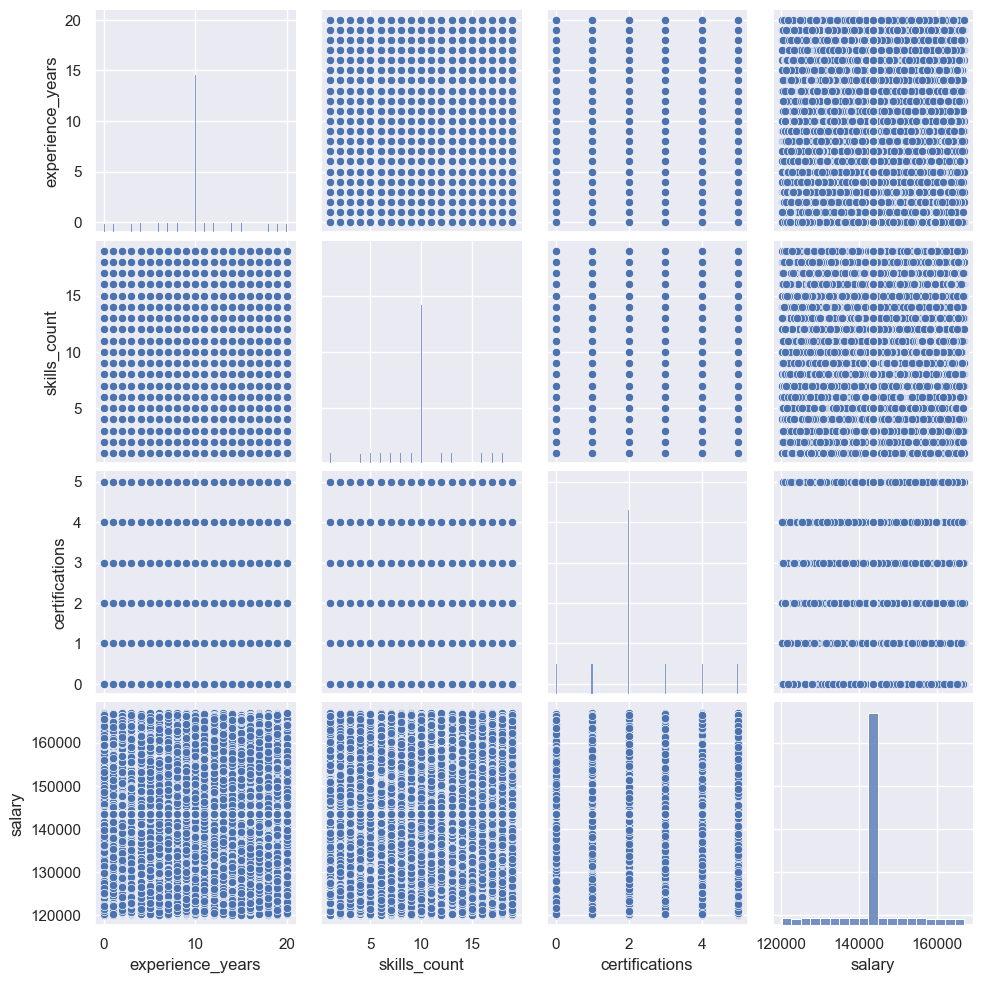

In [18]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.show()

In [19]:
# Grouping example (important for report)
if 'experience_years' in df.columns:
    print(df.groupby('experience_years')['salary'].mean())

experience_years
0.0     142172.045214
1.0     142298.435806
2.0     142297.110423
3.0     142303.362541
4.0     142482.496685
5.0     142579.157921
6.0     142572.083456
7.0     142898.307980
8.0     142998.796738
9.0     143141.264087
10.0    143301.989723
11.0    143651.819294
12.0    143716.185778
13.0    143896.003959
14.0    143996.819649
15.0    144205.599951
16.0    144434.466903
17.0    144477.640525
18.0    144661.473884
19.0    144727.391920
20.0    144605.770608
Name: salary, dtype: float64


In [20]:
df.to_csv("cleaned_dataset.csv", index=False)